# Speaker Verification: RESUME ResNet-34 (Cosine Triplet Loss, 5s Audio)


In [1]:
import os
import pandas as pd
import numpy as np

# ── Training data ──────────────────────────────────────────────────────────────
DATASET_ROOT   = "/kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset"
BASE_AUDIO_DIR = os.path.join(DATASET_ROOT, "train-clean-100", "train-clean-100")
CSV_PATH       = os.path.join(DATASET_ROOT, "train_pairs.csv")

# ── Test data ──────────────────────────────────────────────────────────────────
TEST_ROOT      = "/kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset"
TEST_AUDIO_DIR = os.path.join(TEST_ROOT, "test-clean")
TEST_CSV       = os.path.join(TEST_ROOT, "test_pairs.csv")

print("Train audio:", BASE_AUDIO_DIR)
print("Test audio: ", TEST_AUDIO_DIR)

Train audio: /kaggle/input/datasets/tahmidulislamomi/ml-project-openslr-dataset/train-clean-100/train-clean-100
Test audio:  /kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset/test-clean


In [2]:
df = pd.read_csv(CSV_PATH)

def to_absolute_path(rel_path):
    cleaned = rel_path.replace("train-clean-100/", "", 1)
    return os.path.join(BASE_AUDIO_DIR, cleaned)

def get_speaker_id(rel_path):
    return rel_path.split("/")[1]   # "train-clean-100/311/..." → "311"

df["path1_abs"]   = df["audio_path_1"].apply(to_absolute_path)
df["path2_abs"]   = df["audio_path_2"].apply(to_absolute_path)
df["speaker1_id"] = df["audio_path_1"].apply(get_speaker_id)
df["speaker2_id"] = df["audio_path_2"].apply(get_speaker_id)

print(f"Total rows: {len(df)} | Unique speakers: {df['speaker1_id'].nunique()}")

Total rows: 50000 | Unique speakers: 251


In [3]:
import torch
import torchaudio.transforms as T

TARGET_SR     = 16000
TARGET_LENGTH = TARGET_SR * 5   # 80000 samples (5 Seconds)

def crop_or_pad(audio, is_train=True):
    length = len(audio)
    if length > TARGET_LENGTH:
        start = (np.random.randint(0, length - TARGET_LENGTH) if is_train
                 else (length - TARGET_LENGTH) // 2)
        audio = audio[start:start + TARGET_LENGTH]
    elif length < TARGET_LENGTH:
        audio = np.pad(audio, (0, TARGET_LENGTH - length), mode='constant')
    return audio

mel_transform   = T.MelSpectrogram(sample_rate=16000, n_fft=400, hop_length=160, n_mels=80)
amplitude_to_db = T.AmplitudeToDB()
print("Transforms ready. Target duration: 5 seconds.")

Transforms ready. Target duration: 5 seconds.


In [4]:
import soundfile as sf
from collections import defaultdict
from torch.utils.data import Dataset

class TripletDataset(Dataset):
    def __init__(self, dataframe, mel_transform, amplitude_to_db):
        self.mel_transform   = mel_transform
        self.amplitude_to_db = amplitude_to_db

        self.speaker_to_paths = defaultdict(list)
        for _, row in dataframe.iterrows():
            self.speaker_to_paths[row["speaker1_id"]].append(row["path1_abs"])
            self.speaker_to_paths[row["speaker2_id"]].append(row["path2_abs"])

        self.samples = [(p, spk)
                        for spk, paths in self.speaker_to_paths.items()
                        for p in paths]
        self.all_speakers = list(self.speaker_to_paths.keys())

    def __len__(self): return len(self.samples)

    def load_audio(self, path, is_train=True):
        audio, sr = sf.read(path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = crop_or_pad(audio, is_train=is_train)
        audio = torch.tensor(audio).float().unsqueeze(0)
        return self.amplitude_to_db(self.mel_transform(audio))

    def __getitem__(self, idx):
        anchor_path, anchor_spk = self.samples[idx]
        pos_candidates = [p for p in self.speaker_to_paths[anchor_spk] if p != anchor_path]
        if not pos_candidates: pos_candidates = self.speaker_to_paths[anchor_spk]
        pos_path = pos_candidates[np.random.randint(len(pos_candidates))]
        neg_spk = anchor_spk
        while neg_spk == anchor_spk:
            neg_spk = self.all_speakers[np.random.randint(len(self.all_speakers))]
        neg_path = self.speaker_to_paths[neg_spk][np.random.randint(len(self.speaker_to_paths[neg_spk]))]
        return (self.load_audio(anchor_path), self.load_audio(pos_path), self.load_audio(neg_path))

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class ResNetSpeaker(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.backbone = models.resnet34(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.embedding = nn.Linear(in_features, embedding_dim)

    def forward(self, x):
        features  = self.backbone(x)
        embedding = self.embedding(features)
        return F.normalize(embedding, p=2, dim=1)

In [6]:
from torch.utils.data import DataLoader
import os
from tqdm import tqdm

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ResNetSpeaker(embedding_dim=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

class CosineTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin
    def forward(self, anchor, positive, negative):
        sim_pos = F.cosine_similarity(anchor, positive)
        sim_neg = F.cosine_similarity(anchor, negative)
        return torch.clamp(sim_neg - sim_pos + self.margin, min=0.0).mean()

criterion = CosineTripletLoss(margin=0.3)

NUM_EPOCHS  = 30
start_epoch = 0
loss_history, acc_history, sim_pos_history, sim_neg_history = [], [], [], []

# ─── RESUME LOGIC ───
CHECKPOINT_PATH = "/kaggle/input/datasets/arin10001/checkpoint-triplet-loss/checkpoint_resnet34_cosine_triplet.pth"

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint: {CHECKPOINT_PATH}")
    cp = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(cp['model_state'])
    optimizer.load_state_dict(cp['optimizer_state'])
    start_epoch = cp['epoch'] + 1
    loss_history = cp.get('loss_history', [])
    acc_history = cp.get('acc_history', [])
    sim_pos_history = cp.get('sim_pos_history', [])
    sim_neg_history = cp.get('sim_neg_history', [])
    print(f"Resuming from Epoch {start_epoch + 1}")

train_loader = DataLoader(TripletDataset(df, mel_transform, amplitude_to_db), batch_size=16, shuffle=True)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss, total_correct, total_samples, total_pos, total_neg = 0,0,0,0,0
    
    bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for anc, pos, neg in bar:
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        optimizer.zero_grad()
        e_a, e_p, e_n = model(anc), model(pos), model(neg)
        loss = criterion(e_a, e_p, e_n)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            sp = F.cosine_similarity(e_a, e_p)
            sn = F.cosine_similarity(e_a, e_n)
            total_correct += (sp > sn).sum().item()
            total_samples += anc.size(0)
            total_pos += sp.sum().item()
            total_neg += sn.sum().item()
            total_loss += loss.item()
            bar.set_postfix(loss=f"{loss.item():.4f}")
            
    loss_history.append(total_loss / len(train_loader))
    acc_history.append(total_correct / total_samples)
    sim_pos_history.append(total_pos / total_samples)
    sim_neg_history.append(total_neg / total_samples)
    
    torch.save({
        'model_state': model.state_dict(), 
        'optimizer_state': optimizer.state_dict(), 
        'epoch': epoch,
        'loss_history': loss_history, 
        'acc_history': acc_history,
        'sim_pos_history': sim_pos_history, 
        'sim_neg_history': sim_neg_history
    }, "checkpoint_resnet34_cosine_triplet.pth")


Loading checkpoint: /kaggle/input/datasets/arin10001/checkpoint-triplet-loss/checkpoint_resnet34_cosine_triplet.pth
Resuming from Epoch 28


Epoch 30/30: 100%|██████████| 6250/6250 [1:05:44<00:00,  1.58it/s, loss=0.0000]


## Training History Graphs

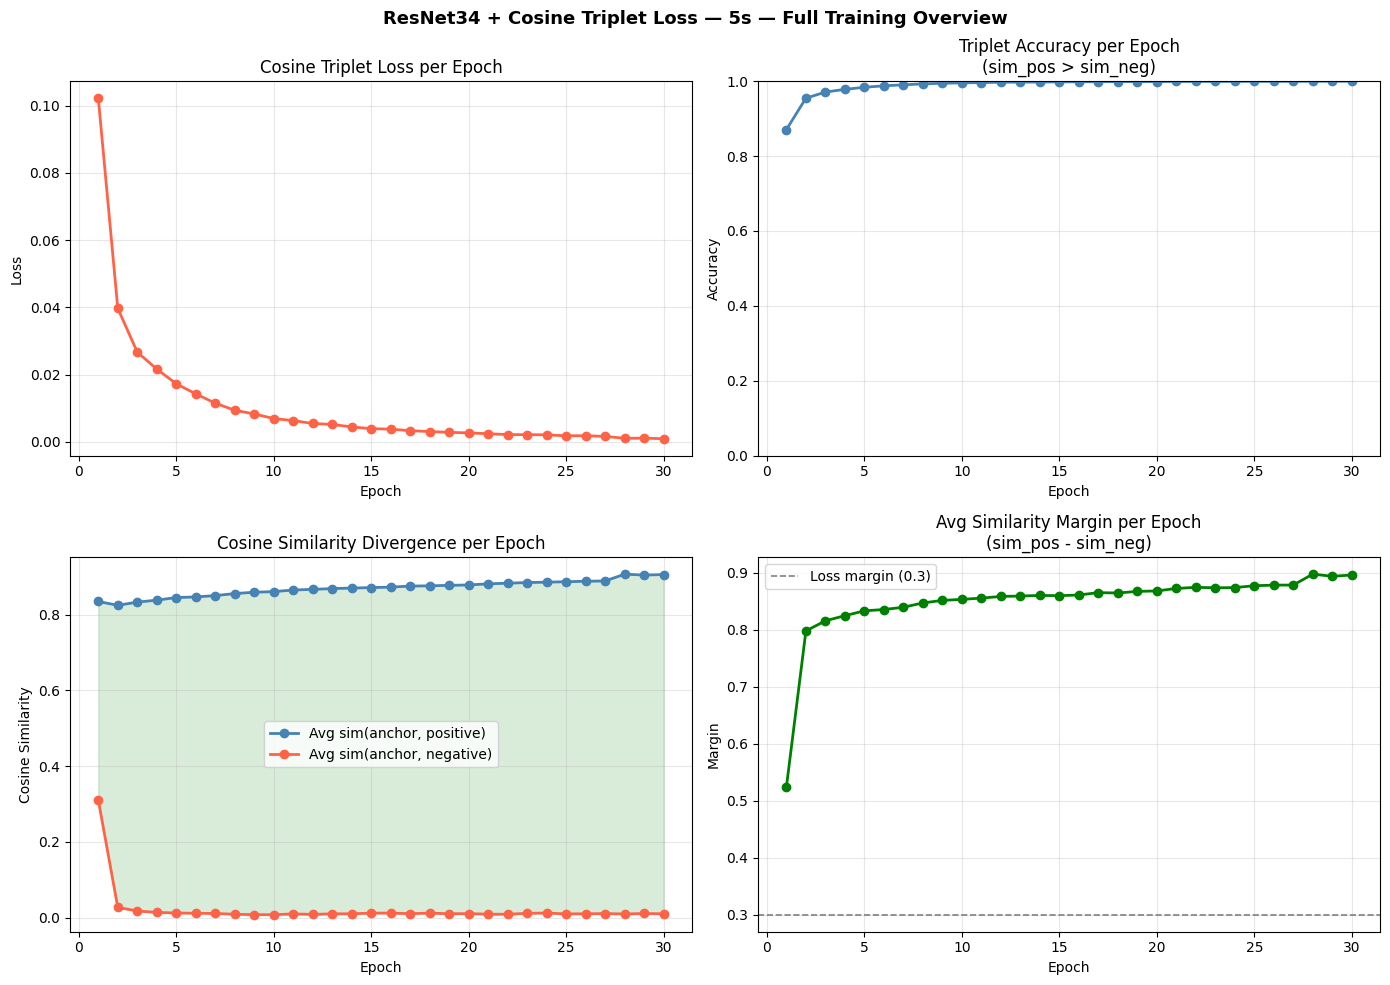

Saved → training_overview_cosine_triplet.png


In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(loss_history) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ResNet34 + Cosine Triplet Loss — 5s — Full Training Overview', fontsize=13, fontweight='bold')

axes[0, 0].plot(epochs_range, loss_history, marker='o', color='tomato', linewidth=2)
axes[0, 0].set_title('Cosine Triplet Loss per Epoch')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, acc_history, marker='o', color='steelblue', linewidth=2)
axes[0, 1].set_title('Triplet Accuracy per Epoch\n(sim_pos > sim_neg)')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0, 1); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs_range, sim_pos_history, marker='o', color='steelblue', linewidth=2, label='Avg sim(anchor, positive)')
axes[1, 0].plot(epochs_range, sim_neg_history, marker='o', color='tomato', linewidth=2, label='Avg sim(anchor, negative)')
axes[1, 0].fill_between(epochs_range, sim_pos_history, sim_neg_history, alpha=0.15, color='green')
axes[1, 0].set_title('Cosine Similarity Divergence per Epoch')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Cosine Similarity')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

margin_history = [p - n for p, n in zip(sim_pos_history, sim_neg_history)]
axes[1, 1].plot(epochs_range, margin_history, marker='o', color='green', linewidth=2)
axes[1, 1].axhline(y=0.3, color='gray', linestyle='--', linewidth=1.2, label='Loss margin (0.3)')
axes[1, 1].set_title('Avg Similarity Margin per Epoch\n(sim_pos - sim_neg)')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Margin')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_overview_cosine_triplet.png', dpi=150)
plt.show()
print('Saved → training_overview_cosine_triplet.png')

## Evaluate Accuracy on Both Datasets

Uses **cosine similarity > 0.5** to predict Same/Different speaker.

In [8]:
from torch.utils.data import DataLoader

class SpeakerPairDataset(Dataset):
    def __init__(self, dataframe, mel_transform, amplitude_to_db):
        self.df              = dataframe
        self.mel_transform   = mel_transform
        self.amplitude_to_db = amplitude_to_db
    def __len__(self): return len(self.df)
    def load_audio(self, path):
        audio, sr = sf.read(path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = crop_or_pad(audio, is_train=False)
        audio = torch.tensor(audio).float().unsqueeze(0)
        return self.amplitude_to_db(self.mel_transform(audio))
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        mel1  = self.load_audio(row['path1_abs'])
        mel2  = self.load_audio(row['path2_abs'])
        label = torch.tensor(row['label']).float()
        return mel1, mel2, label

def evaluate_pairs(model, loader, device, label_name='Set'):
    from tqdm import tqdm
    model.eval()
    correct = 0; total = 0
    same_sims, diff_sims = [], []
    with torch.no_grad():
        for mel1, mel2, labels in tqdm(loader, desc=f'Evaluating {label_name}'):
            mel1, mel2, labels = mel1.to(device), mel2.to(device), labels.to(device)
            emb1 = model(mel1); emb2 = model(mel2)
            sim   = F.cosine_similarity(emb1, emb2)
            preds = (sim > 0.5).float()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            for s, lbl in zip(sim.cpu().tolist(), labels.cpu().tolist()):
                (same_sims if lbl == 1 else diff_sims).append(s)
    acc = correct / total
    print(f'{label_name} Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    return acc, same_sims, diff_sims

# Load test CSV
test_df = pd.read_csv(TEST_CSV)
test_df['path1_abs'] = test_df['audio_path_1'].apply(lambda r: os.path.join(TEST_AUDIO_DIR, r))
test_df['path2_abs'] = test_df['audio_path_2'].apply(lambda r: os.path.join(TEST_AUDIO_DIR, r))

# Train pair loader
train_pair_dataset = SpeakerPairDataset(df, mel_transform, amplitude_to_db)
train_pair_loader  = DataLoader(train_pair_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
# Test pair loader
test_pair_dataset  = SpeakerPairDataset(test_df, mel_transform, amplitude_to_db)
test_pair_loader   = DataLoader(test_pair_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

train_acc, tr_same_sim, tr_diff_sim = evaluate_pairs(model, train_pair_loader, device, 'Training Set')
test_acc,  te_same_sim, te_diff_sim = evaluate_pairs(model, test_pair_loader,  device, 'Test Set')
print(f'\nTrain Acc: {train_acc*100:.2f}%  |  Test Acc: {test_acc*100:.2f}%')
print(f'Generalisation Gap: {(train_acc - test_acc)*100:.2f}%')

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/tahmidulislamomi/ml-project-testing-dataset/test_pairs.csv'

## Accuracy Comparison Bar Chart

In [ ]:
plt.figure(figsize=(7, 5))
bars = plt.bar(['Training Accuracy', 'Test Accuracy'],
               [train_acc, test_acc],
               color=['steelblue', 'darkorange'], width=0.4, edgecolor='white')
for bar, val in zip(bars, [train_acc, test_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val*100:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('ResNet34 + Cosine Triplet 5s — Train vs Test Accuracy', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison_cosine_triplet.png', dpi=150)
plt.show()
print('Saved → accuracy_comparison_cosine_triplet.png')

## Cosine Similarity Distribution — Training vs Test

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Cosine Similarity Distribution (Train vs Test)', fontsize=13, fontweight='bold')

for ax, same, diff, title in [
    (axes[0], tr_same_sim[:5000], tr_diff_sim[:5000], 'Training Set'),
    (axes[1], te_same_sim[:5000], te_diff_sim[:5000], 'Test Set'),
]:
    ax.hist(same, bins=60, alpha=0.6, color='steelblue', label='Same Speaker (label=1)')
    ax.hist(diff, bins=60, alpha=0.6, color='tomato',    label='Different Speaker (label=0)')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
    ax.set_title(title)
    ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Count')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cosine_sim_dist_cosine_triplet.png', dpi=150)
plt.show()
print('Saved → cosine_sim_dist_cosine_triplet.png')

## Final Summary

In [ ]:
print('=' * 47)
print('  MODEL:  ResNet34 + Cosine Triplet Loss (5s)')
print('-' * 47)
print(f'  Training Accuracy : {train_acc*100:.2f}%')
print(f'  Test Accuracy     : {test_acc*100:.2f}%')
print(f'  Generalisation Gap: {(train_acc - test_acc)*100:.2f}%')
print(f'  Total Epochs Done : {len(loss_history)}')
print('=' * 47)
print('Saved files:')
print('  checkpoint_resnet34_cosine_triplet.pth')
print('  training_overview_cosine_triplet.png')
print('  accuracy_comparison_cosine_triplet.png')
print('  cosine_sim_dist_cosine_triplet.png')